# Notebook 1 of 3 — Data, Labels and Frozen-DINOv2 Probes

**Part of the project:** *Self-Supervised (DINOv2) vs. Supervised CNN Representations for Galaxy Morphology Classification*

| | |
|---|---|
| **This notebook does** | Downloads GZ2, builds the 5 morphology classes, creates the fixed train / val / test split, extracts frozen-DINOv2 embeddings, and trains the two probe models |
| **Steps covered** | 1 – 6c, 7a, 7b (models 1 and 2) |
| **Models trained here** | **Model 1** — DINOv2 (frozen) + MLP probe · **Model 2** — DINOv2 (frozen) + linear probe |
| **Saves to Google Drive** | `gz2_subset_images.zip`, `working_dataset.csv`, `embeddings.npz`, `records_nb1_probes.pkl`, `config.json` |
| **Next** | **Notebook 2** (ResNet-18 from scratch) — it reads the files saved here |
| **Runtime** | Google Colab, **T4 GPU** (`Runtime → Change runtime type`) |

# Self-Supervised (DINOv2) vs. Supervised CNN Representations for Galaxy Morphology Classification
### A rigorous, multi-seed label-efficiency and ablation study

**Course project — Machine Learning**

| At a glance | |
|---|---|
| **Task** | Classify galaxy images into 5 morphology (shape) classes |
| **Data** | Galaxy Zoo 2 (GZ2) images together with volunteer vote fractions |
| **Models compared** | Frozen DINOv2 + MLP probe, frozen DINOv2 + linear probe, fine-tuned DINOv2, ResNet-18 from scratch, ImageNet-pretrained ResNet-18 |
| **Main question** | Does a self-supervised model need fewer labelled galaxies than a supervised CNN to reach the same accuracy? |
| **Metrics** | Accuracy, macro-F1, per-class precision / recall / F1, and computational cost (parameters, time, memory) |
| **Rigour** | 6 label fractions × 5 random seeds, mean ± std, 95% confidence intervals, paired significance tests |
| **Run environment** | Google Colab with a GPU (`Runtime → Change runtime type → T4 / A100 GPU`) |

## How the Three Notebooks Fit Together

**Why three notebooks?** On free Colab a session can end at any time (idle time-out, maximum run-time, GPU quota), and when it ends the local disk `/content` is **wiped**. The full experiment contains well over a hundred training runs, so it cannot be relied upon to finish in one sitting. The project is therefore cut into three notebooks. Each one is short enough to finish in one sitting and hands its results over to the next one through a **folder on your Google Drive**.

```text
 Notebook 1 ──►  Drive:  images zip · dataset CSV · embeddings · probe results · config
      │
      ▼
 Notebook 2 ──►  reads Notebook 1's files  ──►  adds ResNet-18 (from scratch) results
      │
      ▼
 Notebook 3 ──►  reads Notebook 2's files  ──►  adds ResNet-18 (ImageNet) + fine-tuned DINOv2,
                                                 then runs ALL analysis (Steps 8 – 18)
```

| Notebook | Steps | Models trained | Reads from Drive | Writes to Drive |
|---|---|---|---|---|
| **1 — Data & frozen DINOv2 probes** | 1 – 6c, 7a, 7b | 1 (DINOv2 + MLP), 2 (DINOv2 + linear) | *(downloads GZ2 itself)* | `gz2_subset_images.zip`, `working_dataset.csv`, `embeddings.npz`, `records_nb1_probes.pkl`, `config.json` |
| **2 — ResNet-18 from scratch** | 1, 5 (reload), 6d, 7a, 7b | 3 (ResNet-18 scratch) | everything from Notebook 1 | `records_nb2_scratch.pkl` |
| **3 — Transfer models & full analysis** | 1, 5 (reload), 6d, 6e, 7a, 7c, 8 – 18 | 4 (ResNet-18 ImageNet), 5 (fine-tuned DINOv2) | everything from Notebooks 1 and 2 | `records_nb3_final.pkl`, `results/*.csv`, `figures/*.png` |

**Folder created on your Drive** (`full` for the real run, `quick` for the trial run — the two never mix):

```text
MyDrive/galaxy_project/full/
├── config.json               ← settings, class names, class weights (written by Notebook 1)
├── working_dataset.csv       ← one row per image: image path, class label, train/val/test
├── gz2_subset_images.zip     ← only the galaxy images actually used (not the whole GZ2 download)
├── embeddings.npz            ← frozen-DINOv2 embeddings for train / val / test
├── records_nb1_probes.pkl    ← results of models 1 and 2
├── records_nb2_scratch.pkl   ← results of models 1, 2 and 3      (cumulative)
├── records_nb3_final.pkl     ← results of all five models         (cumulative)
├── figures/                  ← every figure, saved as PNG
└── results/                  ← every table, saved as CSV, plus the auto-generated summary
```

**Rules for using this on free Colab**

1. **Runtime → Change runtime type → T4 GPU** for all three notebooks.
2. **Run the notebooks in order (1 → 2 → 3)**, each one from top to bottom (*Runtime → Run all*).
3. **Approve the Google Drive pop-up at the start** of every notebook — it appears in the first few cells, so do it before walking away.
4. `QUICK_MODE` is chosen **only in Notebook 1**. In Notebooks 2 and 3 you set `RUN_NAME` to match (`"quick"` or `"full"`); they then read all other settings from `config.json`.
5. **If Colab disconnects:** reconnect and simply *Run all* again. Every finished training run is written to Drive immediately and is **skipped** on the re-run, so you lose at most the one run that was in progress.
6. If you ever re-run an *earlier* notebook from scratch (for example with different settings), **delete the later notebooks' `records_*.pkl` files** on Drive first, so that old and new results are not mixed.
7. Run the **last cell** of each notebook (it flushes Drive) before closing the tab.
8. **Recommended order of work:** do one complete pass through all three notebooks with `QUICK_MODE = True` (a trial run to prove that everything works), then repeat with `QUICK_MODE = False`.

> **In simple words:** Google Drive is the "baton" in a relay race. Each notebook finishes its leg, puts everything the next runner needs into the Drive folder, and the next notebook picks it up — even if Colab was reset in between.

## How to Read This Notebook

Every step in this project follows the same three-part pattern, so that you always know the reason for a step before you see its code:

- **Why?** — the reason the step is needed and the question it helps to answer.
- **What?** — what exactly is produced or decided in the step.
- **How?** — the method used and the main functions involved.

Whenever a technical idea appears, a short **In simple words** note explains it in everyday language. A glossary ("Key Terms in Plain Language") is given before the steps begin. **Step numbers are the same in all three notebooks**, so they can be cited directly in the report.

**Roadmap of the whole project** (the *Notebook* column shows where each step lives)

| Step | Title | Purpose in one line | Notebook |
|---|---|---|---|
| 1 | Setup and configuration | Prepare libraries, device and experiment settings | 1 (short version in 2, 3) |
| 2 | Data acquisition | Download the GZ2 images and volunteer votes | 1 |
| 3 | Defining morphology classes | Turn vote fractions into 5 well-defined classes | 1 |
| 4 | Working dataset and class imbalance | Build a manageable, fair dataset and set class weights | 1 |
| 5 | Preprocessing, augmentation and splits | Prepare images and create fixed train / validation / test sets | 1 (reloaded in 2, 3) |
| 6 | Models | Define the five models that are compared | 6a–6c: 1 · 6d: 2, 3 · 6e: 3 |
| 7 | Multi-seed, multi-fraction experiments | Train and test every model repeatedly on shrinking label budgets | 7b models 1–2: **1** · 7b model 3: **2** · 7c models 4–5: **3** |
| 8 | Aggregated results | Mean ± std and 95% CI; label-efficiency curve | 3 |
| 9 | Statistical significance | Check whether differences are real or due to chance | 3 |
| 10 | Per-class precision, recall, F1 | See which classes are easy or hard | 3 |
| 11 | Confusion matrices | See which classes get mixed up | 3 |
| 12 | Error analysis | Summarise the weakest classes and most frequent confusions | 3 |
| 13 | t-SNE of embeddings | Visualise how DINOv2 organises galaxies | 3 |
| 14 | Attention visualisation | See where DINOv2 "looks" in a galaxy image | 3 |
| 15 | Computational efficiency | Compare parameters, time and memory | 3 |
| 16 | Ablation studies | Find out which design choice gives the gain | 3 |
| 17 | Comparison with AstroDINO | Place our numbers in the context of the source paper | 3 |
| 18 | Auto-generated results summary | Produce discussion text from the computed numbers | 3 |

## Problem Statement

### Background — why does this matter?
The *shape* of a galaxy (its **morphology**) — whether it is round and smooth, a spiral, or a thin disc seen edge-on — gives important clues about how the galaxy formed and how it has evolved. Deep-learning classifiers can assign these shape classes automatically, but the usual *supervised* approach needs thousands of images that humans have already labelled. Labelling is slow and costly: the Galaxy Zoo project relied on a very large volunteer effort even for a few lakh galaxies. Upcoming surveys such as Euclid and the Vera C. Rubin Observatory's LSST are expected to image billions of galaxies, so labelling everything by hand is simply not possible.

### The problem
**Labelled galaxy images are scarce, while unlabelled images are plentiful.** *Self-supervised* models such as DINOv2 learn useful image features without any labels. The open question is:

> **If we freeze a self-supervised DINOv2 model (which has never seen a galaxy label) and train only a tiny classifier on its features, can it match or beat a supervised CNN trained on the same small set of galaxy labels?**

More formally: given galaxy images *x* and five morphology classes *y* derived from Galaxy Zoo 2 votes, and a labelled-data budget *f* ∈ {1%, 5%, 10%, 25%, 50%, 100%} of the training set, we compare the test performance of five models under **identical** data splits, preprocessing and evaluation rules.

### Research questions

| # | Research question | Answered in |
|---|---|---|
| RQ1 | With all labels available, how does a frozen DINOv2 + MLP probe compare with a supervised ResNet-18? | Steps 8, 9 |
| RQ2 | As labels become scarce (100% → 1%), does the self-supervised model lose less accuracy than the supervised CNN? | Steps 8, 9 |
| RQ3 | Does a non-linear (MLP) probe beat a plain linear probe on the same frozen features? | Steps 9, 16 |
| RQ4 | Does fine-tuning the last transformer blocks of DINOv2 help further? | Step 16 |
| RQ5 | Which morphology classes are easy or hard, and which pairs are confused? | Steps 10 – 12 |
| RQ6 | What does each approach cost in parameters, training time, inference time and GPU memory? | Step 15 |

### Working hypothesis (to be tested, not assumed)
Features learnt without labels should be more *label-efficient*, so the advantage of DINOv2 should be largest when only 1–10% of labels are available. The source paper's own table (Step 17) shows that CNNs trained from scratch can match or beat frozen DINOv2 when *all* labels are available — so the interesting question is whether this order reverses when labels are scarce. The notebook is designed so that the data can also contradict our hypothesis.

### Scope and success criteria
- **In scope:** a 5-class morphology task on a class-balanced subset of GZ2 (up to 20,000 galaxies), the small DINOv2 ViT-S/14 backbone, five models, six label fractions, five seeds.
- **Success is judged by:** test accuracy and macro-F1 (mean ± std over seeds), paired significance tests, per-class behaviour, and computational cost.
- **Out of scope:** other galaxy surveys, larger DINOv2 backbones, and hyperparameter tuning (see *Limitations and Future Work* at the end).

## Objectives and Contributions

**Objectives**

1. Build a scientifically defensible, documented galaxy-morphology classification task from GZ2.
2. Reproduce the frozen-DINOv2 + MLP-probe pipeline of AstroDINO on this task.
3. Compare it against a linear probe (ablation), a fine-tuned DINOv2 (new model), a from-scratch ResNet-18 and an ImageNet-pretrained ResNet-18 — under **identical** splits, preprocessing and evaluation protocol.
4. Measure label efficiency (1–100% of labels) using 5-seed mean ± std and significance testing.
5. Report per-class metrics, confusion matrices and a qualitative error analysis.
6. Report and compare computational cost (parameters, time, memory) alongside accuracy.
7. Compare our absolute numbers with AstroDINO's reported Table 1 accuracies, with proper caveats.

**What is reproduced from the source paper** — Manwadkar & Kapare, *"AstroDINO: Self-Supervised Learning on Astronomical Images"* (Stanford, 2025) [ref. 3]:
- Using a pretrained, **frozen** DINOv2 backbone as a feature extractor for galaxy images.
- Training a small MLP probe (1 hidden layer, 256 units, ReLU) on top of the frozen embeddings.
- Evaluating on Galaxy Zoo morphology labels.
- Visualising DINO attention maps as an unsupervised-segmentation-style qualitative check.

**What is this project's own contribution (not in the source paper)**
- A scientifically motivated, documented class scheme built from GZ2 debiased vote fractions with published reliability thresholds (Willett et al. 2013), instead of an arbitrary label rule.
- A **fine-tuned DINOv2** model (last transformer blocks unfrozen) as an additional comparison point.
- A **linear-probe vs. MLP-probe** ablation on the frozen DINOv2 features.
- A **label-efficiency sweep** at 1%, 5%, 10%, 25%, 50% and 100% of the labelled training data.
- **5 random seeds** per (model, label-fraction) cell, with mean ± std and 95% confidence intervals.
- **Paired significance tests** (paired t-test and Wilcoxon signed-rank test).
- **Per-class precision / recall / F1**, confusion matrices and an error analysis for the two headline models.
- A **computational-efficiency comparison**: parameter counts, training time, inference time and peak GPU memory.
- A results summary that is **generated from the notebook's own computed numbers** (Step 18), not hand-written placeholders.

## Key Terms in Plain Language

| Term | Meaning in simple words |
|---|---|
| **Galaxy morphology** | The visible shape and structure of a galaxy — for example round, spiral or edge-on disc. |
| **Galaxy Zoo 2 (GZ2)** | A citizen-science project in which volunteers answered a series of questions about each galaxy image. |
| **Vote fraction** | The share of volunteers who chose a particular answer. *Debiased* means it has been adjusted so that faint or distant galaxies are not unfairly labelled. |
| **Supervised learning** | Learning from examples that come with human-given labels ("this is a spiral"). |
| **Self-supervised learning (SSL)** | Learning useful patterns from images *without* any labels, by solving a puzzle that the images themselves provide. |
| **DINOv2** | A self-supervised model from Meta AI that learns general-purpose image features from a very large collection of ordinary photographs. |
| **Vision Transformer (ViT-S/14)** | A network design that cuts an image into small square patches (here 14 × 14 pixels) and studies how the patches relate to one another. "S" stands for the small version. |
| **Backbone** | The main part of a network that converts an image into numbers. |
| **Embedding (feature vector)** | The list of numbers (384 for this model) that summarises what the network "sees" in one image. |
| **Frozen** | The weights are locked and are not changed during our training. |
| **Probe (linear / MLP)** | A small classifier trained on top of frozen embeddings. *Linear* = a single layer. *MLP* (multi-layer perceptron) = one extra hidden layer with a non-linear step, so it can learn more complex decision boundaries. |
| **Fine-tuning** | Continuing to train some of the pretrained weights on our own task, usually with a small learning rate. |
| **ResNet-18** | A classic 18-layer convolutional neural network (CNN). *From scratch* = random starting weights. *ImageNet-pretrained* = starts from weights already learnt on the ImageNet photo collection. |
| **Label efficiency** | How well a model performs when only a small share of the training labels is available. |
| **Data augmentation** | Creating slightly changed copies of training images (flips, rotations) so that the model learns to ignore changes that do not matter. |
| **Class imbalance and class weights** | Some classes have far fewer images than others. Class weights make mistakes on rare classes count more during training. |
| **Stratified sampling / split** | Picking images class by class so that every class is represented in the right proportion. |
| **Train / validation / test set** | *Train*: the model learns from it. *Validation*: kept aside for tuning choices. *Test*: used only at the end for an honest evaluation. |
| **Accuracy** | The share of galaxies classified correctly. |
| **Precision, recall, F1** | *Precision*: of the galaxies predicted as class X, how many really are X. *Recall*: of the galaxies that really are X, how many were found. *F1*: one score that combines both. **Macro-F1** is the simple average of F1 over all classes, so rare classes count equally. |
| **Mean ± std, 95% CI** | *Mean*: average over seeds. *Std*: how much the results vary between seeds. *95% CI*: the range in which the true average is expected to lie with 95% confidence. |
| **p-value, paired t-test, Wilcoxon test** | The p-value is the chance of seeing a difference at least this large if the two models were actually equal; below 0.05 suggests a real difference. Both tests compare two models seed by seed; the Wilcoxon test does not assume that the differences follow a bell curve. |
| **Confusion matrix** | A table of true class versus predicted class; the diagonal shows correct predictions. |
| **t-SNE** | A method that squeezes high-dimensional embeddings into a 2-D picture; points that are close together are similar. |
| **Attention map** | A picture showing which parts of the image the transformer pays most attention to. |

## Step 1 — Setup and Configuration

**Why?**
A research experiment must be repeatable: anyone who runs this notebook should obtain the same kind of results. This needs the same libraries, a known computing device (GPU or CPU) and a fixed set of experiment settings. The full experiment is also heavy, so we need a way to test the whole pipeline quickly before the long run.

**What?**
- Install and import the required libraries.
- Choose the computing device.
- Fix the experiment settings: random seeds, label fractions, number of training epochs and dataset size.

**How?**
- `pip install` fetches `galaxy-datasets` (data), `torch`, `torchvision`, `timm` (deep learning) and `scikit-learn`, `scipy`, `statsmodels`, `pandas`, `seaborn` (metrics, statistics and plots).
- `DEVICE` selects the GPU automatically when one is available.
- `QUICK_MODE` switches between two sets of settings:

| Setting | `QUICK_MODE = True` (trial run) | `QUICK_MODE = False` (full protocol) |
|---|---|---|
| Seeds | 2 (0, 1) | 5 (0 – 4) |
| Label fractions | 5%, 25%, 100% | 1%, 5%, 10%, 25%, 50%, 100% |
| CNN epochs | 5 | 15 |
| Fine-tuning epochs | 3 | 8 |
| Probe epochs | 20 | 30 |
| Dataset size | 4,000 galaxies | 20,000 galaxies |

> **In simple words:** A *seed* is a number that fixes the "randomness" of an experiment (which images are picked, how the weights start). Repeating an experiment with 5 different seeds tells us whether a result is stable or just lucky. An *epoch* is one complete pass through the training images.

**Note on compute budget.** The full grid (6 label fractions × 5 seeds × 5 models) is expensive. Frozen-DINOv2 probes are cheap to retrain because the embeddings are computed only once; retraining the CNNs and the fine-tuned DINOv2 is the costly part. A sensible workflow is to run once with `QUICK_MODE = True` to confirm that everything works, and then switch to `False` for the final run.

**Where the settings go.** `QUICK_MODE` is chosen **here, once**. At the end of this notebook every setting is saved to `config.json` on Google Drive, and Notebooks 2 and 3 read it from there, so all three notebooks always use identical settings. The Google Drive pop-up appears in the cells right below — approve it now, before the long download starts.

In [1]:
!pip install -q galaxy-datasets torch torchvision timm scikit-learn seaborn pandas scipy statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.4/73.4 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 64.1 MB/s eta 0:00:00


In [2]:
import os, time, random, math, json, itertools, copy, gc, pickle, shutil, zipfile
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              confusion_matrix, classification_report)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from scipy import stats as sstats

# Use the GPU if Colab has allotted one; otherwise fall back to the (much slower) CPU.
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# ---- Compute-budget switch ----
# QUICK_MODE=True : quick trial run (fewer seeds / fractions / epochs) to confirm that the whole
#                   pipeline works from start to end before committing to the full run.
# QUICK_MODE=False: the FULL protocol -- 5 seeds and the complete 1-100% label-efficiency sweep.
QUICK_MODE = False

if QUICK_MODE:
    SEEDS = [0, 1]
    FRACTIONS = [0.05, 0.25, 1.0]
    CNN_EPOCHS = 5
    FT_EPOCHS = 3
    PROBE_EPOCHS = 20
    N_DATASET = 4000
else:
    SEEDS = [0, 1, 2, 3, 4]
    FRACTIONS = [0.01, 0.05, 0.10, 0.25, 0.50, 1.00]
    CNN_EPOCHS = 15
    FT_EPOCHS = 8
    PROBE_EPOCHS = 30
    N_DATASET = 20000  # increase further if Colab disk/RAM permit

print(f"QUICK_MODE={QUICK_MODE} | seeds={SEEDS} | fractions={FRACTIONS} | N_DATASET={N_DATASET}")

Using device: cuda
QUICK_MODE=False | seeds=[0, 1, 2, 3, 4] | fractions=[0.01, 0.05, 0.1, 0.25, 0.5, 1.0] | N_DATASET=20000


In [3]:
# ---- Google Drive = the bridge between the three notebooks ----
from google.colab import drive
drive.mount("/content/drive")

RUN_NAME    = "quick" if QUICK_MODE else "full"      # keeps trial-run files and full-run files apart
PROJECT_DIR = f"/content/drive/MyDrive/galaxy_project/{RUN_NAME}"
FIG_DIR     = f"{PROJECT_DIR}/figures"
RES_DIR     = f"{PROJECT_DIR}/results"
for d in (PROJECT_DIR, FIG_DIR, RES_DIR):
    os.makedirs(d, exist_ok=True)
print("Project folder on Drive:", PROJECT_DIR)


# ---- Helpers that make every experiment loop RESUMABLE ---------------------------------------
# After every finished run the full list of results ("records") is written to Google Drive.
# If Colab disconnects, re-running the notebook reloads that file and skips all finished runs.

def save_records(records, path):
    tmp = path + ".tmp"                      # write to a temporary file first, so that a disconnect
    with open(tmp, "wb") as f:               # in the middle of writing cannot corrupt the real file
        pickle.dump(records, f)
    try:
        os.replace(tmp, path)
    except OSError:
        shutil.copyfile(tmp, path); os.remove(tmp)

def load_records(path):
    with open(path, "rb") as f:
        return pickle.load(f)

def run_key(model, fraction, seed):
    # A run is identified by (model, label fraction, seed).
    return (model, round(float(fraction), 6), int(seed))

def done_keys(records):
    return {run_key(r["model"], r["fraction"], r["seed"]) for r in records}

def quick_preview(records):
    # Mean / std / count of test accuracy per (model, fraction) -- a quick look at progress.
    rows = [dict(model=r["model"], fraction=r["fraction"], seed=r["seed"],
                 accuracy=accuracy_score(r["y_true"], r["preds"])) for r in records]
    return (pd.DataFrame(rows).groupby(["model", "fraction"])["accuracy"]
              .agg(["mean", "std", "count"]).round(4))

Mounted at /content/drive
Project folder on Drive: /content/drive/MyDrive/galaxy_project/full


## Step 2 — Data Acquisition

**Why?**
We need galaxy images with reliable shape information. Galaxy Zoo 2 is a standard benchmark and is the same underlying label source that the source paper uses, which keeps our study comparable in spirit.

**What?**
The GZ2 *catalogue* (a table with one row per galaxy, holding the image path `file_loc` and the volunteer vote fractions) and the galaxy images themselves.

**How?**
The maintained `galaxy-datasets` package (Walmsley et al.) downloads both. `gz2(root, train=True, download=True)` returns the catalogue as a pandas table and the list of label columns. We print the table's shape and the names of the fraction columns, because Step 3 finds the required columns by their names.

> **In simple words:** Each galaxy was shown to many volunteers who answered questions such as "Is the galaxy smooth or does it have features?". The catalogue stores what share of volunteers gave each answer.

**What to check:** the printed list should contain names ending in `_fraction`. Look at them once by eye before moving on.

In [4]:
from galaxy_datasets import gz2

DATA_DIR = "/content/gz2_data"
os.makedirs(DATA_DIR, exist_ok=True)

# catalog = table with one row per galaxy; label_cols = names of the volunteer-vote columns.
catalog, label_cols = gz2(root=DATA_DIR, train=True, download=True)
print("Catalogue shape:", catalog.shape)
print("Number of label columns:", len(label_cols))
# Look at the actual column names before relying on the matching logic in Step 3.
# Different galaxy-datasets versions name the columns slightly differently
# (e.g. 'smooth-or-featured-gz2_smooth_fraction' vs 'smooth-or-featured_smooth_fraction'),
# so print the list once and check it by eye.
print([c for c in label_cols if "fraction" in c][:30])

100%|██████████| 22392239/22392239 [00:00<00:00, 24923297.48it/s]


100%|██████████| 5852873/5852873 [00:00<00:00, 46821465.82it/s]


100%|██████████| 2671470353/2671470353 [01:27<00:00, 30411508.16it/s]


Extracting /content/gz2_data/images_gz2.tar.gz to /content/gz2_data
Catalogue shape: (167434, 90)
Number of label columns: 30
[]


## Step 3 — Scientifically Grounded Morphology Labels *(our contribution)*

**Why?**
Labels are the ground truth for everything that follows. GZ2 does not give one class per galaxy; it gives vote fractions for a tree of questions. If we convert these into classes with an arbitrary rule (for example, an `argmax` over whichever columns load first), the results become hard to defend. We therefore follow the published GZ2 "clean sample" scheme (Willett et al. 2013, *MNRAS* 435:2835; Hart et al. 2016).

**What?**
Five well-separated, astrophysically meaningful classes, each defined by thresholds on the GZ2 debiased vote fractions, plus a minimum-vote-count reliability cut:

| Class | Definition (GZ2 debiased vote fractions) |
|---|---|
| 0 — Round smooth (elliptical) | smooth branch, `p_round ≥ 0.5` |
| 1 — In-between smooth | smooth branch, `p_in_between ≥ 0.5` |
| 2 — Cigar-shaped smooth | smooth branch, `p_cigar ≥ 0.5` |
| 3 — Edge-on disk | featured / disk branch, `p_edgeon ≥ 0.715` |
| 4 — Spiral (face-on) | featured / disk branch, not edge-on, `p_spiral ≥ 0.619` |

Galaxies that meet none of these thresholds with adequate votes (ambiguous or low-confidence morphology) are **dropped**. This is standard practice for building "clean" GZ2-derived datasets — a deliberate, documented filtering step, not a missing-data problem.

**How?**
1. Find the required column names automatically by matching substrings (Step 3a) rather than hard-coding column positions.
2. Apply a minimum-vote-count cut (N ≥ 10) where a vote-count column exists.
3. Walk down the GZ2 decision tree for every galaxy (Step 3b), as shown below, and print the class sizes as a sanity check.

```text
Smooth or featured?
├── Smooth (fraction ≥ 0.5)  →  best of: Round | In-between | Cigar-shaped   (each needs ≥ 0.5)
└── Featured / disk          →  Edge-on? (≥ 0.715)  →  Class 3: Edge-on disk
                                 else Spiral arms? (≥ 0.619)  →  Class 4: Spiral
                                 else → dropped as ambiguous
```

> **In simple words:** We copy the way volunteers were asked the questions. First ask "smooth or featured?", and only then ask the follow-up question that belongs to that branch. Galaxies on which volunteers did not agree clearly are left out, so that the labels we train on are trustworthy.

**Design note — why the order of the checks matters.** The `round`, `in-between` and `cigar` columns are *conditional* vote fractions: they mean something only for galaxies that volunteers first called "smooth". An earlier version of this notebook checked them for every galaxy without first looking at the smooth-vs-featured vote. That wrongly pushed about 97.6% of galaxies into a smooth class and left only 62 edge-on disks out of 1,67,114 galaxies. The corrected logic applies the top-level smooth-vs-featured gate first, exactly as the GZ2 decision tree does, and only then looks inside the relevant branch. Edge-on disks are still genuinely rarer than round or spiral galaxies, so the remaining imbalance is handled by class-weighted loss (Step 4) and stratified subsampling (Step 7).

**Check before you run.** Based on the package's label metadata, the resolved columns should look like `smooth-or-featured-gz2_smooth_fraction`, `how-rounded-gz2_round_fraction`, `how-rounded-gz2_in-between_fraction`, `how-rounded-gz2_cigar_fraction`, `disk-edge-on-gz2_yes_fraction` and `has-spiral-arms-gz2_yes_fraction` (exact spelling can vary between package versions). Because the matching works on substrings, a column such as `bulge-shape-gz2_round_fraction`, which also contains "round", could be picked by mistake if it appears earlier in the table. Compare the printed "Resolved columns" with the list above before trusting the class counts.

### Step 3a — Locate the required columns
**Why?** Column names differ slightly between package versions. **What?** The seven columns needed for labelling (smooth, round, in-between, cigar, edge-on, spiral and, optionally, a vote count). **How?** `find_col()` returns the first column whose name contains all the given substrings; the cell then stops with a clear error message if any required column is missing, and applies the vote-count cut if a count column exists.

In [5]:
def find_col(candidates_substrings, cols):
    # Return the first column whose name contains ALL the given substrings (upper/lower case ignored).
    for c in cols:
        cl = c.lower()
        if all(s in cl for s in candidates_substrings):
            return c
    return None

cols = list(catalog.columns)

col_smooth      = find_col(["smooth-or-featured", "smooth", "fraction"], cols)
col_featured    = find_col(["smooth-or-featured", "featured", "fraction"], cols) or find_col(["disk", "fraction"], cols)
col_round       = find_col(["round", "fraction"], cols)
col_inbetween   = find_col(["in-between", "fraction"], cols) or find_col(["inbetween", "fraction"], cols)
col_cigar       = find_col(["cigar", "fraction"], cols)
col_edgeon      = find_col(["edge-on", "yes", "fraction"], cols) or find_col(["edgeon", "yes", "fraction"], cols)
col_spiral      = find_col(["spiral-arms", "yes", "fraction"], cols) or find_col(["has-spiral", "yes", "fraction"], cols)

# Vote-count column for a minimum-reliability cut (in the style of Willett et al. 2013).
# Not every galaxy-datasets version stores this under the same name, so it is optional:
# if it is not found, we skip the count-based cut and rely on the fraction thresholds alone.
col_smooth_count = (find_col(["smooth-or-featured", "count"], cols)
                     or find_col(["smooth-or-featured", "total-votes"], cols)
                     or find_col(["smooth-or-featured", "total_votes"], cols))

found = {
    "smooth": col_smooth, "round": col_round, "in_between": col_inbetween, "cigar": col_cigar,
    "edgeon": col_edgeon, "spiral": col_spiral, "smooth_count (optional)": col_smooth_count,
}
print("Resolved columns:", found)
assert all(found[k] is not None for k in ["smooth", "round", "in_between", "cigar", "edgeon", "spiral"]), (
    "One or more required vote-fraction columns could not be resolved automatically -- run print(cols) "
    "and adjust the substrings in find_col() to match your galaxy-datasets version before proceeding."
)

MIN_VOTES = 10
if col_smooth_count is not None:
    before = len(catalog)
    catalog = catalog[catalog[col_smooth_count] >= MIN_VOTES].copy()
    print(f"Applied minimum-vote-count reliability cut (N>={MIN_VOTES} on {col_smooth_count}): "
          f"{len(catalog)} / {before} galaxies retained.")
else:
    print("No vote-count column resolved for this schema version -- skipping the count-based "
          "reliability cut; the fraction thresholds in Step 3 still apply.")

Resolved columns: {'smooth': 'smooth-or-featured-gz2_smooth_fraction', 'round': 'how-rounded-gz2_round_fraction', 'in_between': 'how-rounded-gz2_in-between_fraction', 'cigar': 'how-rounded-gz2_cigar_fraction', 'edgeon': 'disk-edge-on-gz2_yes_fraction', 'spiral': 'has-spiral-arms-gz2_yes_fraction', 'smooth_count (optional)': 'smooth-or-featured-gz2_total-votes'}
Applied minimum-vote-count reliability cut (N>=10 on smooth-or-featured-gz2_total-votes): 167434 / 167434 galaxies retained.


### Step 3b — Assign one class to each galaxy
**Why?** The models need a single class label per image. **What?** A `label` column with values 0 – 4, and the "clean" table with ambiguous galaxies removed. **How?** `assign_gz2_class()` applies the decision-tree logic described above row by row; galaxies that get `-1` are dropped. The printed class counts and the max / min class ratio tell us how imbalanced the clean sample is.

In [6]:
# DESIGN NOTE: the round / in-between / cigar columns are *conditional* debiased vote fractions --
# they mean something only for galaxies that volunteers first called "smooth". So we check the
# top-level smooth-vs-featured fraction FIRST (exactly like the GZ2 decision tree) and only then
# look inside the relevant branch. An earlier version skipped this gate; it pushed ~97.6% of all
# galaxies into a smooth class and left only 62 edge-on disks out of 1,67,114 galaxies.

SMOOTH_GATE = 0.5      # top-level question: smooth vs. featured/disk
SUBCLASS_MIN = 0.5     # within-branch confidence floor

def assign_gz2_class(row):
    if row[col_smooth] >= SMOOTH_GATE:
        # Smooth branch: take the best-supported of round / in-between / cigar.
        smooth_opts = {0: row[col_round], 1: row[col_inbetween], 2: row[col_cigar]}
        best_class, best_frac = max(smooth_opts.items(), key=lambda kv: kv[1])
        return best_class if best_frac >= SUBCLASS_MIN else -1
    else:
        # Featured/disk branch.
        if row[col_edgeon] >= 0.715:
            return 3  # edge-on disk
        if row[col_spiral] >= 0.619:
            return 4  # face-on spiral
        return -1  # ambiguous within the featured branch -> dropped

CLASS_NAMES = ["Round smooth", "In-between smooth", "Cigar-shaped smooth", "Edge-on disk", "Spiral"]
N_CLASSES = len(CLASS_NAMES)

catalog["label"] = catalog.apply(assign_gz2_class, axis=1)
clean = catalog[catalog["label"] >= 0].copy()

print(f"Retained {len(clean)} / {len(catalog)} galaxies after clean-sample filtering "
      f"({100*len(clean)/len(catalog):.1f}%).")
print("\nClass distribution (clean sample, after gating fix):")
dist = clean["label"].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES)))
print(dist)
imbalance_ratio = dist.max() / dist.min()
print(f"\nMax/min class-count ratio: {imbalance_ratio:.1f}x")
if imbalance_ratio > 10:
    print("Still notably imbalanced -- Step 4 applies class-weighted loss during training as "
          "a second safeguard on top of this fix, and Step 7 uses stratified (per-class) "
          "subsampling for the label-efficiency sweep so that every fraction retains all 5 classes.")

Retained 157299 / 167434 galaxies after clean-sample filtering (93.9%).

Class distribution (clean sample, after gating fix):
label
Round smooth           44726
In-between smooth      63624
Cigar-shaped smooth    16143
Edge-on disk            5192
Spiral                 27614
Name: count, dtype: int64

Max/min class-count ratio: 12.3x
Still notably imbalanced -- Step 4 applies class-weighted loss during training as a second safeguard on top of this fix, and Step 7 uses stratified (per-class) subsampling for the label-efficiency sweep so that every fraction retains all 5 classes.


## Step 4 — Working Dataset and Class Imbalance

**Why?**
- Training 5 models × 6 label fractions × 5 seeds on the whole GZ2 catalogue (well over a lakh of galaxies) is too heavy for a Colab session, so a smaller working dataset is needed.
- If one class has far fewer images than the others, a model can score a high accuracy by mostly predicting the big classes and ignoring the rare one.

**What?**
- A working dataset of up to `N_DATASET` galaxies (20,000 in the full run) with an equal cap of `N_DATASET / 5` galaxies per class. A class with fewer galaxies than the cap keeps all of them.
- A vector of *class weights* used in the loss function of every model.

**How?**
- `groupby("label")` followed by `sample(...)` draws at most `per_class_cap` galaxies from each class (fixed `random_state`, so the subset is the same every time).
- `compute_class_weight("balanced")` gives each class the weight *N ÷ (K × nᶜ)*, where *N* is the total number of galaxies, *K* the number of classes and *nᶜ* the size of class *c*. Rare classes therefore get larger weights, and these weights are passed to `CrossEntropyLoss` for every model.

> **In simple words:** Class weights are like giving extra marks for getting a rare class right (and extra penalty for missing it), so that the model does not simply "play safe" by always guessing the common classes.

**What to check:** the bar chart and the printed table should show all five classes. If the smallest class is still very small, read its results with extra caution.

Final dataset size: 20000
label
Round smooth           4000
In-between smooth      4000
Cigar-shaped smooth    4000
Edge-on disk           4000
Spiral                 4000
Name: count, dtype: int64


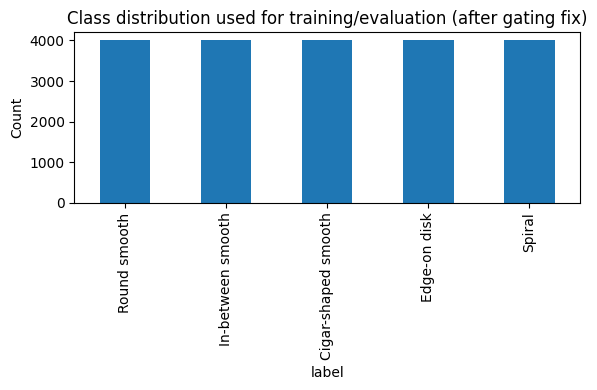


Balanced class weights (used in CrossEntropyLoss for every model below):
  Round smooth: 1.000
  In-between smooth: 1.000
  Cigar-shaped smooth: 1.000
  Edge-on disk: 1.000
  Spiral: 1.000


In [7]:
# Cap the dataset size (equal number of galaxies per class, wherever available) so that training
# stays practical on Colab. Increase N_DATASET in Step 1 if your compute budget allows a larger run.
per_class_cap = max(1, N_DATASET // N_CLASSES)
# (Written as an explicit loop instead of groupby(...).apply(...): recent pandas versions drop the
#  grouping column inside .apply, which would silently remove the "label" column.)
sub = pd.concat(
    [g.sample(min(len(g), per_class_cap), random_state=0) for _, g in clean.groupby("label")]
).reset_index(drop=True)

print("Final dataset size:", len(sub))
dist2 = sub["label"].value_counts().sort_index().rename(index=dict(enumerate(CLASS_NAMES)))
print(dist2)

fig, ax = plt.subplots(figsize=(6, 4))
dist2.plot(kind="bar", ax=ax)
ax.set_ylabel("Count"); ax.set_title("Class distribution used for training/evaluation (after gating fix)")
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=150); plt.show()

# Second safeguard for any leftover imbalance: class-weighted loss. Even after fixing the gating,
# the real GZ2 population has fewer edge-on disks than round or spiral galaxies. We therefore
# compute "balanced" (inverse-frequency) class weights and pass them to every CrossEntropyLoss
# below, so that mistakes on rarer classes cost more and the model cannot get away with simply
# predicting the majority class.
class_weights_np = compute_class_weight(class_weight="balanced", classes=np.arange(N_CLASSES), y=sub["label"].values)
CLASS_WEIGHTS = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print("\nBalanced class weights (used in CrossEntropyLoss for every model below):")
for name, w in zip(CLASS_NAMES, class_weights_np):
    print(f"  {name}: {w:.3f}")

min_class_count = dist2.min()
if min_class_count < 50:
    print(f"\nNote: the smallest class still has only {min_class_count} examples after capping. "
          f"Class-weighted loss (above) and stratified per-class label-fraction sampling (Step 7) "
          f"reduce this problem, but results for this class should be read with wider uncertainty in mind.")

## Step 5 — Preprocessing, Augmentation and Data Splits

**Why?**
Pretrained networks expect images of a fixed size and brightness scale. Augmentation helps the models to generalise, and — most importantly for a fair comparison — every model in every experiment must be tested on exactly the same unseen images.

**What?**
Image transforms, a fixed 70 / 15 / 15 train / validation / test split, and a small `Dataset` class that reads an image and its label.

**How?**
- **Resize:** all images to 224 × 224 (the standard input size for DINOv2 and ResNet-18).
- **Normalisation:** ImageNet channel mean and standard deviation, matching what the pretrained backbones expect.
- **Training-time augmentation:** random horizontal flip (p = 0.5) and random rotation (±15°). The orientation of a galaxy on the sky is arbitrary, so flips and rotations do not change its class and are standard for this domain. **No colour jitter** is used, because colour carries real physical information (stellar population, redshift proxies) that we do not want to disturb.
- **Split:** stratified 70 / 15 / 15 by class, **fixed across all models and experiments** (same `random_state`), so every model in every comparison in Steps 8 – 16 sees exactly the same test set.
- **Label-fraction subsampling (Step 7):** done only *inside* the fixed training split, so the validation and test sets never change or shrink across fractions.
- **Validation set:** it is reserved for future tuning. In this notebook all models use fixed learning rates and epoch counts, so the test set is touched only for the final evaluation.

> **In simple words:** *Normalisation* rescales pixel values to the range the pretrained model was trained on. *Augmentation* shows the model rotated and mirrored versions of the same galaxy so that it does not learn to depend on the sky angle.

In [8]:
# Stratified 70/15/15 split. The same random_state is used everywhere, so every model sees
# exactly the same train / validation / test images.
train_df, temp_df = train_test_split(sub, test_size=0.30, stratify=sub["label"], random_state=0)
val_df, test_df    = train_test_split(temp_df, test_size=0.50, stratify=temp_df["label"], random_state=0)
print(f"train={len(train_df)}  val={len(val_df)}  test={len(test_df)}")

# In this notebook the images are read from their original download location.
# (Notebooks 2 and 3 read them from the copy that Step 5b saves to Drive.)
train_df = train_df.assign(img_path=train_df["file_loc"])
val_df   = val_df.assign(img_path=val_df["file_loc"])
test_df  = test_df.assign(img_path=test_df["file_loc"])

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Reads one image from disk, applies the chosen transform and returns (image tensor, class label).
class GalaxyImageDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True); self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = self.transform(Image.open(row["img_path"]).convert("RGB"))
        return img, int(row["label"])

train_ds_aug   = GalaxyImageDataset(train_df, train_transform)
train_ds_plain = GalaxyImageDataset(train_df, eval_transform)
val_ds         = GalaxyImageDataset(val_df, eval_transform)
test_ds        = GalaxyImageDataset(test_df, eval_transform)

train=14000  val=3000  test=3000


### Step 5b — Save the working dataset to Google Drive *(hand-off to Notebooks 2 and 3)*

**Why?** The downloaded GZ2 files live on Colab's local disk, which is wiped when the session ends. Notebooks 2 and 3 must use **exactly the same images and exactly the same train / validation / test split**, otherwise their results cannot be compared with the probes trained here.

**What?**
- `gz2_subset_images.zip` — only the galaxy images actually used in this study (not the whole GZ2 download).
- `working_dataset.csv` — one row per image with three columns: `img_rel` (image path inside the zip), `label` (class 0 – 4) and `split` (`train` / `val` / `test`). The row order (train, then val, then test) is the same order in which the embeddings are computed in Step 6b.

**How?** The JPEG files are stored in the zip without further compression (they are already compressed), which is fast. The zip is copied to Drive under a temporary name and renamed only when the copy is complete, so a disconnect cannot leave a half-written file behind.

In [9]:
ZIP_DRIVE = f"{PROJECT_DIR}/gz2_subset_images.zip"
CSV_DRIVE = f"{PROJECT_DIR}/working_dataset.csv"

# Row order = train, val, test (the same order in which embeddings are extracted in Step 6b).
ds_all = pd.concat([train_df.assign(split="train"),
                    val_df.assign(split="val"),
                    test_df.assign(split="test")], ignore_index=True)
ds_all["img_rel"] = [f"images/{i:05d}{os.path.splitext(p)[1]}" for i, p in enumerate(ds_all["file_loc"])]

if os.path.exists(ZIP_DRIVE) and os.path.exists(CSV_DRIVE):
    print("Working dataset already saved on Drive -- skipping (delete the two files to redo this step).")
else:
    t0 = time.time()
    ZIP_LOCAL = "/content/gz2_subset_images.zip"
    with zipfile.ZipFile(ZIP_LOCAL, "w", compression=zipfile.ZIP_STORED) as zf:
        for src, rel in zip(ds_all["file_loc"], ds_all["img_rel"]):
            zf.write(src, arcname=rel)
    shutil.copyfile(ZIP_LOCAL, ZIP_DRIVE + ".part")
    os.replace(ZIP_DRIVE + ".part", ZIP_DRIVE)                       # rename only when the copy is complete
    ds_all[["img_rel", "label", "split"]].to_csv(CSV_DRIVE, index=False)
    print(f"Saved {len(ds_all)} images ({os.path.getsize(ZIP_DRIVE)/1e6:.0f} MB zip) and the dataset table "
          f"to Drive in {time.time()-t0:.0f}s.")
print(ds_all["split"].value_counts().to_dict())

Saved 20000 images (277 MB zip) and the dataset table to Drive in 12s.
{'train': 14000, 'val': 3000, 'test': 3000}


## Step 6 — Models

**Why?**
Each research question in the problem statement needs a specific model to answer it. All models must be trained and tested in the same way, so that any difference in results comes from the model and not from the setup.

**What?** Five models:

| # | Model | What is trained | Purpose |
|---|---|---|---|
| 1 | **DINOv2 (frozen) + MLP probe** | Small MLP only | Reproduction of the source paper's pipeline |
| 2 | **DINOv2 (frozen) + linear probe** | One linear layer only | Ablation: does the non-linearity of the MLP matter? |
| 3 | **ResNet-18 (from scratch)** | Whole network, random start | Supervised baseline without pretraining |
| 4 | **ResNet-18 (ImageNet fine-tuned)** | Whole network, ImageNet start | Supervised baseline with transfer learning |
| 5 | **DINOv2 (fine-tuned)** | Last 2 transformer blocks + linear head | Our extension: does adapting the backbone help? |

The numbering above is the same as in the experiment loops of Step 7.

**How?**
Sub-steps 6a – 6e below load the DINOv2 backbone, compute its embeddings once, and define the training helpers for the probes, the ResNet-18 models and the fine-tuned DINOv2.

> **Where each model is defined:** 6a – 6c (the DINOv2 backbone, embeddings and probes) are in **this notebook**. 6d (ResNet-18) is in **Notebooks 2 and 3**, and 6e (fine-tuned DINOv2) is in **Notebook 3**.

### Step 6a — Load the DINOv2 backbone
**Why?** It is the pretrained feature extractor for models 1, 2 and 5. **What?** DINOv2 ViT-S/14 (the small version), which turns each image into a 384-number embedding. **How?** `torch.hub.load` fetches it from Meta AI's repository; `freeze()` switches off gradient updates; `count_params()` counts (trainable) parameters for the efficiency table in Step 15.

In [10]:
# Load the pretrained DINOv2 ViT-S/14 backbone (weights are fetched from Meta AI via torch.hub).
dinov2_backbone = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
dinov2_backbone.eval().to(DEVICE)
EMBED_DIM = dinov2_backbone.embed_dim
print("DINOv2 embed dim:", EMBED_DIM)

# Freezing = switching off gradient updates, so the weights stay exactly as pretrained.
def freeze(model):
    for p in model.parameters():
        p.requires_grad = False

def count_params(model, trainable_only=True):
    return sum(p.numel() for p in model.parameters() if (p.requires_grad or not trainable_only))

Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vits14/dinov2_vits14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vits14_pretrain.pth


100%|██████████| 84.2M/84.2M [00:00<00:00, 260MB/s]


DINOv2 embed dim: 384


### Step 6b — Extract embeddings once
**Why?** With a frozen backbone the embeddings never change, so computing them once saves a great deal of time: every probe, for every fraction and seed, can then be trained in seconds. **What?** Embeddings and labels for the train, validation and test sets. **How?** `extract_embeddings()` passes each image through the backbone in batches with gradients switched off; the total time is stored in `dino_extract_time`. The training embeddings use the plain (non-augmented) images.

> **In simple words:** The backbone acts like a fixed "translator" that converts every galaxy picture into a short list of numbers. The probes only learn to classify those lists.

**Saved to Drive:** the embeddings are stored in `embeddings.npz`. If this cell is re-run after a disconnect, the saved file is loaded instead of recomputing (the stored extraction time is kept, so Step 15 stays correct).

In [11]:
# Pass every image through the frozen backbone ONCE and keep the resulting embeddings
# (one list of numbers per image); the probes are later trained on these stored numbers.
@torch.no_grad()
def extract_embeddings(backbone, dataset, batch_size=64):
    backbone.eval()
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    feats, labels = [], []
    for imgs, y in loader:
        out = backbone(imgs.to(DEVICE))
        feats.append(out.cpu().numpy()); labels.append(y.numpy())
    return np.concatenate(feats), np.concatenate(labels)

freeze(dinov2_backbone)
EMB_PATH = f"{PROJECT_DIR}/embeddings.npz"

if os.path.exists(EMB_PATH):
    z = np.load(EMB_PATH)
    train_feats_full, train_labels_full = z["train_feats_full"], z["train_labels_full"]
    val_feats,  val_labels  = z["val_feats"],  z["val_labels"]
    test_feats, test_labels = z["test_feats"], z["test_labels"]
    dino_extract_time = float(z["dino_extract_time"])
    assert len(train_feats_full) == len(train_df) and len(test_feats) == len(test_df), \
        "Saved embeddings do not match the current dataset -- delete embeddings.npz on Drive and re-run."
    print("Loaded saved embeddings from Drive. Original extraction time (s):", round(dino_extract_time, 1))
else:
    t0 = time.time()
    train_feats_full, train_labels_full = extract_embeddings(dinov2_backbone, train_ds_plain)
    val_feats,  val_labels  = extract_embeddings(dinov2_backbone, val_ds)
    test_feats, test_labels = extract_embeddings(dinov2_backbone, test_ds)
    dino_extract_time = time.time() - t0
    print("Frozen-DINOv2 embedding extraction time (s):", round(dino_extract_time, 1))
    np.savez(f"{PROJECT_DIR}/embeddings_tmp.npz",
             train_feats_full=train_feats_full, train_labels_full=train_labels_full,
             val_feats=val_feats, val_labels=val_labels,
             test_feats=test_feats, test_labels=test_labels,
             dino_extract_time=dino_extract_time)
    os.replace(f"{PROJECT_DIR}/embeddings_tmp.npz", EMB_PATH)
    print("Saved embeddings to Drive:", EMB_PATH)
print("Embedding shapes  train / val / test:", train_feats_full.shape, val_feats.shape, test_feats.shape)

Frozen-DINOv2 embedding extraction time (s): 114.0
Saved embeddings to Drive: /content/drive/MyDrive/galaxy_project/full/embeddings.npz
Embedding shapes  train / val / test: (14000, 384) (3000, 384) (3000, 384)


### Step 6c — Probes (small classifiers on frozen embeddings)
**Why?** To test the source paper's MLP probe (model 1) and a simpler linear probe (model 2). **What?** Two tiny networks: `MLPProbe` (384 → 256 → ReLU → 5) and `LinearProbe` (384 → 5), plus a training function. **How?** `train_probe()` trains with the Adam optimiser and class-weighted cross-entropy loss, fixes the seed for repeatability, and returns predictions together with training and inference times.

In [12]:
# Probe 1 (MLP): one hidden layer of 256 units with a ReLU non-linearity, as in the AstroDINO paper.
class MLPProbe(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=256):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(in_dim, hidden), nn.ReLU(), nn.Linear(hidden, n_classes))
    def forward(self, x): return self.net(x)

# Probe 2 (linear): a single layer with no non-linearity -- used for the ablation.
class LinearProbe(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        self.net = nn.Linear(in_dim, n_classes)
    def forward(self, x): return self.net(x)

# Train a probe on pre-computed embeddings (Adam optimiser, class-weighted cross-entropy loss).
# Returns the trained model, test predictions, training time and inference time per image.
def train_probe(probe_cls, X_train, y_train, X_eval, y_eval, n_classes, epochs, batch_size=64, lr=1e-3,
                 seed=0, class_weights=None):
    torch.manual_seed(seed); np.random.seed(seed)
    model = probe_cls(X_train.shape[1], n_classes).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    crit = nn.CrossEntropyLoss(weight=class_weights)
    ds = torch.utils.data.TensorDataset(torch.tensor(X_train, dtype=torch.float32),
                                         torch.tensor(y_train, dtype=torch.long))
    g = torch.Generator().manual_seed(seed)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True, generator=g)

    t0 = time.time()
    for _ in range(epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
    train_time = time.time() - t0

    model.eval()
    t0 = time.time()
    with torch.no_grad():
        preds = model(torch.tensor(X_eval, dtype=torch.float32).to(DEVICE)).argmax(1).cpu().numpy()
    infer_time_per_img = (time.time() - t0) / max(1, len(X_eval))
    return model, preds, train_time, infer_time_per_img

## Step 7 — Unified Multi-Seed, Multi-Fraction Experiment Loop

**Why?**
A single training run can be lucky or unlucky. To make trustworthy claims we need repeated runs (several seeds), and to study label efficiency we need several label budgets (fractions).

**What?**
A table of records with one row for every (model, fraction, seed) run, holding the predictions on the test set, the number of labelled images used, training and inference times, parameter counts and (for GPU models) peak memory.

**How?**
Every model is retrained from scratch for each (fraction, seed) pair. All runs draw from the same fixed training split and are evaluated on the same fixed test set. For a given (fraction, seed), **all models receive the same labelled subset**, which is what makes the seed-by-seed (paired) tests in Step 9 valid.

> **Step 7 is split across the three notebooks.** This notebook runs **7a** and **7b** (models 1 and 2). Notebook 2 runs model 3, and Notebook 3 runs models 4 and 5 (**7c**). The labelled subset for a given (fraction, seed) is produced by the same formula in every notebook, so **all models still receive exactly the same labelled images** and the paired tests in Step 9 remain valid.

### Step 7a — Stratified subsampling helper
**Why?** With plain random sampling, a small class such as Edge-on disk could receive *zero* examples at 1% labels, silently turning the experiment into a 4-class problem. **What?** A function that returns the indices of a labelled subset. **How?** `stratified_subsample()` samples the chosen fraction *within each class* (at least one image per class), using a seed derived from the run's seed and fraction.

In [13]:
def stratified_subsample(labels_array, frac, seed, n_classes):
    # Stratified (per-class) subsampling for the label-efficiency sweep. Plain random sampling of a
    # tiny class such as Edge-on disk could easily pick ZERO examples of it at frac=0.01, quietly
    # turning that experiment into a 4-class problem. Sampling a fraction from WITHIN each class
    # guarantees that every class appears (at least 1 example) at every label fraction, which keeps
    # the label-efficiency curve comparable across fractions and consistent with the class-weighted loss.
    rng = np.random.RandomState(seed)
    sub_idx = []
    for cls in range(n_classes):
        cls_idx = np.where(labels_array == cls)[0]
        if len(cls_idx) == 0:
            continue
        n_c = len(cls_idx) if frac >= 1.0 else max(1, int(round(len(cls_idx) * frac)))
        n_c = min(n_c, len(cls_idx))
        sub_idx.append(rng.choice(cls_idx, size=n_c, replace=False))
    sub_idx = np.concatenate(sub_idx)
    rng.shuffle(sub_idx)
    return sub_idx

### Step 7b — Models 1 and 2 (frozen-DINOv2 probes) at every fraction
**Why?** These two models give the label-efficiency curve of the self-supervised approach and answer RQ3 (MLP vs. linear probe).
**What?** Frozen DINOv2 + MLP probe and frozen DINOv2 + linear probe, for all fractions × all seeds (in the full run: 6 × 5 = 30 runs per model, 60 in total).
**How?** Both probes reuse the stored embeddings, so each run takes seconds. After every (fraction, seed) pair the results are written to Drive (`records_nb1_probes.pkl`). If the session dies, run the notebook again: finished pairs are skipped and the loop continues where it stopped.

In [14]:
REC_NB1 = f"{PROJECT_DIR}/records_nb1_probes.pkl"
records = load_records(REC_NB1) if os.path.exists(REC_NB1) else []   # resume if a previous attempt exists
done = done_keys(records)
print(f"Already finished (from Drive): {len(records)} runs")

MODEL_MLP, MODEL_LIN = "DINOv2-frozen+MLP", "DINOv2-frozen+Linear"

for frac in FRACTIONS:
    for seed in SEEDS:
        k_mlp, k_lin = run_key(MODEL_MLP, frac, seed), run_key(MODEL_LIN, frac, seed)
        if k_mlp in done and k_lin in done:
            continue
        # Same subset formula in all three notebooks -> every model sees the same labelled images.
        sub_idx = stratified_subsample(train_labels_full, frac, seed=seed * 1000 + int(frac * 100), n_classes=N_CLASSES)
        n_sub = len(sub_idx)

        # --- 1. DINOv2 frozen + MLP probe ---
        if k_mlp not in done:
            _, preds, ttime, itime = train_probe(MLPProbe, train_feats_full[sub_idx], train_labels_full[sub_idx],
                                                  test_feats, test_labels, N_CLASSES, PROBE_EPOCHS, seed=seed,
                                                  class_weights=CLASS_WEIGHTS)
            records.append(dict(model=MODEL_MLP, fraction=frac, seed=seed, n_labeled=n_sub,
                                 preds=preds, y_true=test_labels, train_time=ttime, infer_time=itime,
                                 n_params=count_params(MLPProbe(EMBED_DIM, N_CLASSES))))
            done.add(k_mlp)

        # --- 2. DINOv2 frozen + linear probe (ablation) ---
        if k_lin not in done:
            _, preds, ttime, itime = train_probe(LinearProbe, train_feats_full[sub_idx], train_labels_full[sub_idx],
                                                  test_feats, test_labels, N_CLASSES, PROBE_EPOCHS, seed=seed,
                                                  class_weights=CLASS_WEIGHTS)
            records.append(dict(model=MODEL_LIN, fraction=frac, seed=seed, n_labeled=n_sub,
                                 preds=preds, y_true=test_labels, train_time=ttime, infer_time=itime,
                                 n_params=count_params(LinearProbe(EMBED_DIM, N_CLASSES))))
            done.add(k_lin)

        save_records(records, REC_NB1)          # <- progress is now safe on Drive
        print(f"[frac={frac:.2f} seed={seed}] n_labeled={n_sub} done: MLP + Linear   (total records: {len(records)})")

print("\nModels 1-2 done for all fractions and seeds; records:", len(records))

Already finished (from Drive): 0 runs
[frac=0.01 seed=0] n_labeled=140 done: MLP + Linear   (total records: 2)
[frac=0.01 seed=1] n_labeled=140 done: MLP + Linear   (total records: 4)
[frac=0.01 seed=2] n_labeled=140 done: MLP + Linear   (total records: 6)
[frac=0.01 seed=3] n_labeled=140 done: MLP + Linear   (total records: 8)
[frac=0.01 seed=4] n_labeled=140 done: MLP + Linear   (total records: 10)
[frac=0.05 seed=0] n_labeled=700 done: MLP + Linear   (total records: 12)
[frac=0.05 seed=1] n_labeled=700 done: MLP + Linear   (total records: 14)
[frac=0.05 seed=2] n_labeled=700 done: MLP + Linear   (total records: 16)
[frac=0.05 seed=3] n_labeled=700 done: MLP + Linear   (total records: 18)
[frac=0.05 seed=4] n_labeled=700 done: MLP + Linear   (total records: 20)
[frac=0.10 seed=0] n_labeled=1400 done: MLP + Linear   (total records: 22)
[frac=0.10 seed=1] n_labeled=1400 done: MLP + Linear   (total records: 24)
[frac=0.10 seed=2] n_labeled=1400 done: MLP + Linear   (total records: 26)
[

### Quick look at Notebook 1's results
**Why?** A sanity check before the long runs in Notebooks 2 and 3: the frozen-DINOv2 probes should be clearly better than chance (20% for 5 classes), and accuracy should generally rise with the label fraction. **What?** Mean ± std of test accuracy per (model, fraction). The full analysis (confidence intervals, tests, per-class scores) is done in Notebook 3.

mean     std  count
model                fraction                       
DINOv2-frozen+Linear 0.01      0.5348  0.0104      5
                     0.05      0.6168  0.0139      5
                     0.10      0.6513  0.0062      5
                     0.25      0.6741  0.0051      5
                     0.50      0.6895  0.0063      5
                     1.00      0.6997  0.0068      5
DINOv2-frozen+MLP    0.01      0.5623  0.0072      5
                     0.05      0.6191  0.0191      5
                     0.10      0.6439  0.0084      5
                     0.25      0.6720  0.0101      5
                     0.50      0.6832  0.0102      5
                     1.00      0.6959  0.0113      5

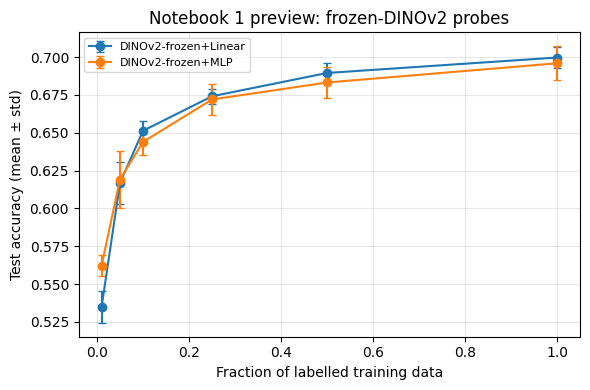

In [15]:
preview = quick_preview(records)
display(preview)

plt.figure(figsize=(6, 4))
for m in preview.index.get_level_values(0).unique():
    g = preview.loc[m].sort_index()
    plt.errorbar(g.index, g["mean"], yerr=g["std"], marker="o", capsize=3, label=m)
plt.xlabel("Fraction of labelled training data"); plt.ylabel("Test accuracy (mean ± std)")
plt.title("Notebook 1 preview: frozen-DINOv2 probes"); plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(FIG_DIR, "nb1_probe_preview.png"), dpi=150); plt.show()

## Hand-off to Notebook 2

**Why?** Notebooks 2 and 3 need every setting and every derived quantity from this notebook (class names, class weights, seeds, fractions, epochs). Saving them once in `config.json` means the later notebooks cannot accidentally use different settings.

**What?** `config.json`, plus a check that all expected files are on Drive. The check also confirms that all 2 × fractions × seeds probe runs are present; if not, it stops with a clear message.

In [16]:
expected_probe_runs = 2 * len(FRACTIONS) * len(SEEDS)
assert len(records) == expected_probe_runs, (
    f"Only {len(records)} of {expected_probe_runs} probe runs are finished -- re-run the Step 7b cell.")

config = dict(
    run_name=RUN_NAME, quick_mode=bool(QUICK_MODE),
    seeds=SEEDS, fractions=FRACTIONS,
    cnn_epochs=CNN_EPOCHS, ft_epochs=FT_EPOCHS, probe_epochs=PROBE_EPOCHS, n_dataset=N_DATASET,
    class_names=CLASS_NAMES, class_weights=[float(w) for w in class_weights_np],
    img_size=IMG_SIZE, embed_dim=int(EMBED_DIM), dino_extract_time=float(dino_extract_time),
    n_train=len(train_df), n_val=len(val_df), n_test=len(test_df),
    probe_records_expected=expected_probe_runs, notebook1_finished=True,
)
with open(f"{PROJECT_DIR}/config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Files on Drive in", PROJECT_DIR)
for name in ["config.json", "working_dataset.csv", "gz2_subset_images.zip", "embeddings.npz", "records_nb1_probes.pkl"]:
    p = f"{PROJECT_DIR}/{name}"
    assert os.path.exists(p), f"MISSING: {name}"
    print(f"  ✅ {name:28s} {os.path.getsize(p)/1e6:9.2f} MB")
print("\n➡️  Notebook 1 finished. Now open Notebook 2 and set RUN_NAME =", repr(RUN_NAME), "there.")

Files on Drive in /content/drive/MyDrive/galaxy_project/full
  ✅ config.json                       0.00 MB
  ✅ working_dataset.csv               0.49 MB
  ✅ gz2_subset_images.zip           276.72 MB
  ✅ embeddings.npz                   30.88 MB
  ✅ records_nb1_probes.pkl            1.47 MB

➡️  Notebook 1 finished. Now open Notebook 2 and set RUN_NAME = 'full' there.


### Final cell — flush Google Drive
Drive writes are buffered. Running this cell (last) forces everything to be written before you close the tab. After it runs, Drive is unmounted — that is expected.

In [17]:
from google.colab import drive
drive.flush_and_unmount()
print("Drive flushed. You can now close this notebook and open Notebook 2.")

Drive flushed. You can now close this notebook and open Notebook 2.
